In [9]:
import pandas as pd
import numpy as np
print(f"Pandas: {pd.__version__}")
print("✅ Ready")

Pandas: 2.1.4
✅ Ready


In [10]:
# Cell 2: Load WM-811K dataset with encoding fix

import pickle
import pandas as pd
import numpy as np
from pathlib import Path
import sys

# Fix 1: old pandas compatibility
import pandas.core.indexes
sys.modules['pandas.indexes'] = pandas.core.indexes

DATA_PATH = Path("../data/raw/LSWMD.pkl")

print("Loading dataset... please wait 2-3 minutes...")

# Fix 2: latin1 encoding fixes the ascii decode error
with open(DATA_PATH, 'rb') as f:
    df = pickle.load(f, encoding='latin1')

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading dataset... please wait 2-3 minutes...

✅ Dataset loaded successfully!
Shape: (811457, 6)
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


In [11]:
# Cell 3: Understand the dataset structure

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total wafer maps : {len(df):,}")
print(f"Total columns    : {len(df.columns)}")

print("\n" + "=" * 50)
print("COLUMN DETAILS")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("SAMPLE WAFER MAP (raw pixel values)")
print("=" * 50)
sample = df['waferMap'].iloc[0]
print(f"Shape: {sample.shape}")
print(f"Unique values: {np.unique(sample)}")
print("0=outside wafer, 1=good chip, 2=defective chip")

DATASET OVERVIEW
Total wafer maps : 811,457
Total columns    : 6

COLUMN DETAILS
waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object

MISSING VALUES
waferMap          0
dieSize           0
lotName           0
waferIndex        0
trianTestLabel    0
failureType       0
dtype: int64

SAMPLE WAFER MAP (raw pixel values)
Shape: (45, 48)
Unique values: [0 1 2]
0=outside wafer, 1=good chip, 2=defective chip


In [12]:
# Cell 4: Analyze defect class distribution
# This is the most important analysis before training

# Extract failure type cleanly
df['failureType_clean'] = df['failureType'].apply(
    lambda x: x[0][0] if isinstance(x, (list, np.ndarray)) 
    and len(x) > 0 and len(x[0]) > 0 else 'none'
)

# Count each class
class_counts = df['failureType_clean'].value_counts()

print("DEFECT CLASS DISTRIBUTION")
print("=" * 45)
for defect, count in class_counts.items():
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"{defect:15} | {count:7,} | {pct:5.1f}% | {bar}")

print(f"\nTotal classes: {len(class_counts)}")
print(f"Imbalance ratio: {class_counts.max() / class_counts.min():.0f}x")

DEFECT CLASS DISTRIBUTION
none            | 785,938 |  96.9% | ████████████████████████████████████████████████
Edge-Ring       |   9,680 |   1.2% | 
Edge-Loc        |   5,189 |   0.6% | 
Center          |   4,294 |   0.5% | 
Loc             |   3,593 |   0.4% | 
Scratch         |   1,193 |   0.1% | 
Random          |     866 |   0.1% | 
Donut           |     555 |   0.1% | 
Near-full       |     149 |   0.0% | 

Total classes: 9
Imbalance ratio: 5275x


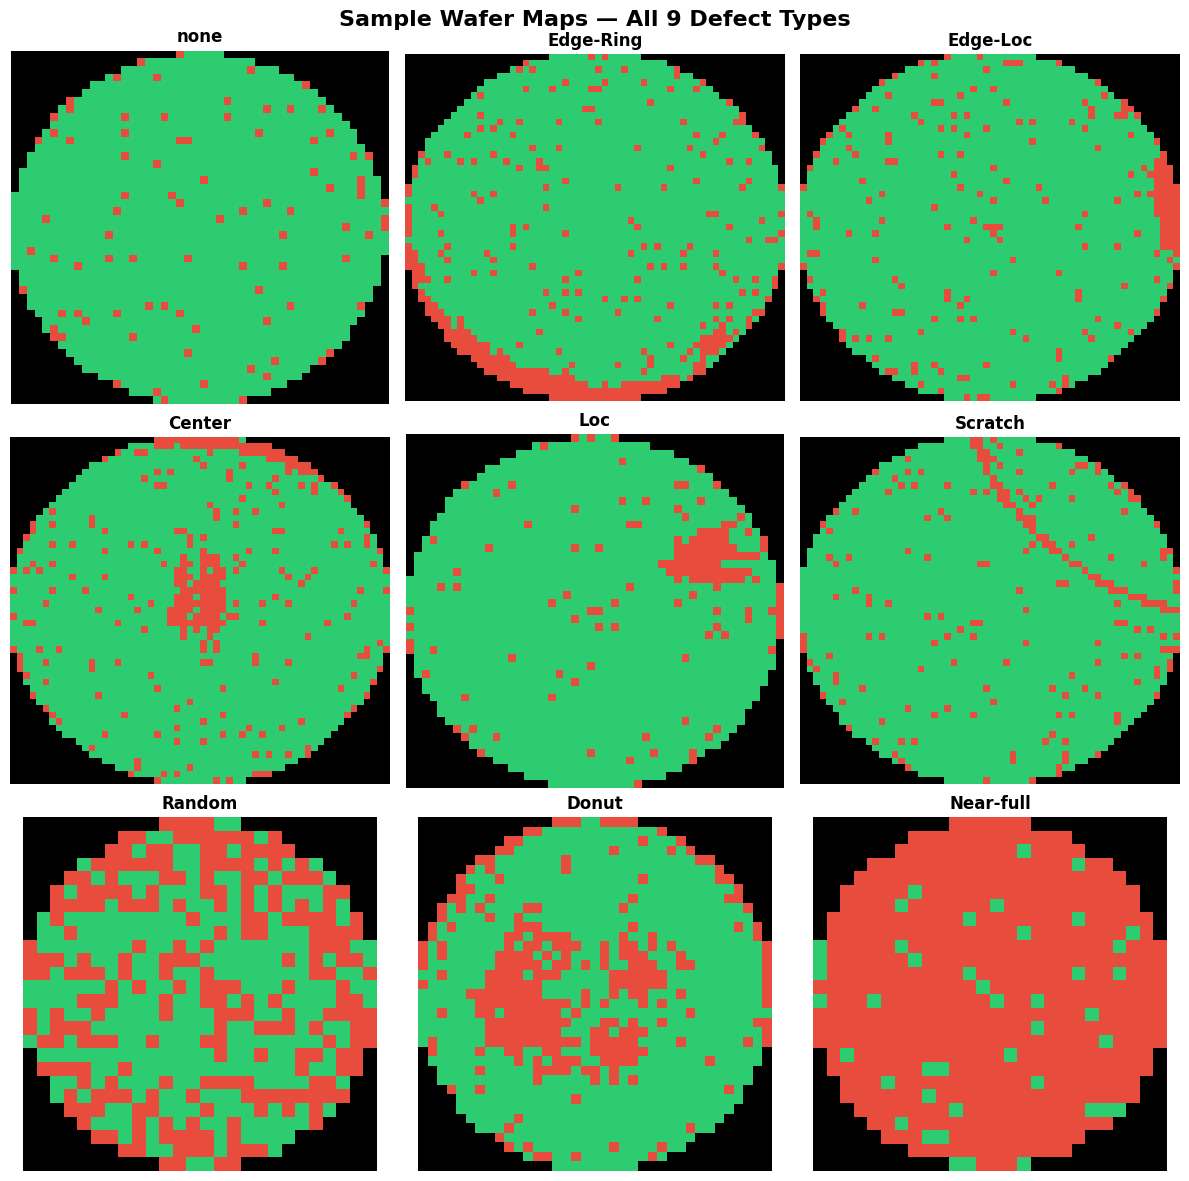

✅ Saved to data/raw/wafer_samples.png


In [13]:
# Cell 5: Visualize actual wafer maps

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

defect_types = class_counts.index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Sample Wafer Maps — All 9 Defect Types', 
             fontsize=16, fontweight='bold')

# Colors: black=outside, green=good, red=defective
cmap = ListedColormap(['black', '#2ecc71', '#e74c3c'])

for idx, defect in enumerate(defect_types):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    sample = df[df['failureType_clean'] == defect]['waferMap'].iloc[0]
    
    ax.imshow(sample, cmap=cmap, vmin=0, vmax=2, 
              interpolation='nearest')
    ax.set_title(f'{defect}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../data/raw/wafer_samples.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to data/raw/wafer_samples.png")

In [14]:
# Cell 6: Save dataset summary — Week 1 Complete!

import json
from pathlib import Path

summary = {
    'total_samples': int(len(df)),
    'total_columns': int(len(df.columns)),
    'defect_classes': {k: int(v) for k, v in class_counts.items()},
    'num_classes': int(len(class_counts)),
    'wafer_map_shape': list(df['waferMap'].iloc[0].shape),
    'missing_values': int(df.isnull().sum().sum()),
    'imbalance_ratio': round(float(class_counts.max() / class_counts.min()), 1),
    'key_findings': [
        "811,457 total wafer maps loaded",
        "9 defect classes identified",
        "Zero missing values — clean dataset",
        "Extreme class imbalance: 5275x ratio",
        "96.9% samples are non-defective (none class)",
        "Near-full defect is rarest: only 149 samples",
        "Each wafer map is 45x48 pixels with values 0,1,2"
    ]
}

summary_path = Path("../data/raw/dataset_summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print("✅ WEEK 1 — DATA EXPLORATION COMPLETE!")
print("=" * 50)
print(f"\n📊 Total wafer maps   : {summary['total_samples']:,}")
print(f"🏷️  Defect classes     : {summary['num_classes']}")
print(f"🧹 Missing values     : {summary['missing_values']}")
print(f"⚠️  Imbalance ratio   : {summary['imbalance_ratio']}x")
print(f"\n📁 Files saved:")
print(f"   ✅ data/raw/wafer_samples.png")
print(f"   ✅ data/raw/dataset_summary.json")
print(f"\n🚀 Ready for Week 2 — Preprocessing & Augmentation!")

✅ WEEK 1 — DATA EXPLORATION COMPLETE!

📊 Total wafer maps   : 811,457
🏷️  Defect classes     : 9
🧹 Missing values     : 0
⚠️  Imbalance ratio   : 5274.8x

📁 Files saved:
   ✅ data/raw/wafer_samples.png
   ✅ data/raw/dataset_summary.json

🚀 Ready for Week 2 — Preprocessing & Augmentation!


Original wafer shape: (53, 58)
Original unique values: [0 1 2]

Processed image shape: (640, 640, 3)
Processed image dtype: uint8


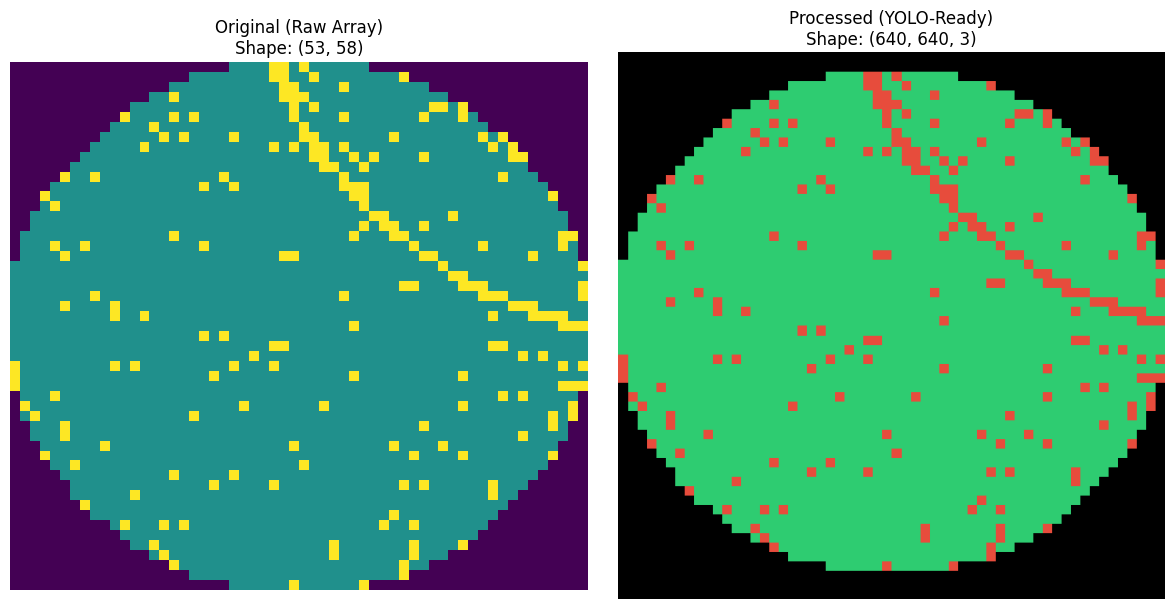


✅ Preprocessing pipeline working on real data!


In [15]:
# Cell 8: Test preprocessor on REAL wafer data

import sys
sys.path.append('..')
from src.data.preprocessor import WaferPreprocessor
import matplotlib.pyplot as plt

preprocessor = WaferPreprocessor(target_size=640)

# Take one real wafer map with a defect
sample_wafer = df[df['failureType_clean'] == 'Scratch']['waferMap'].iloc[0]

print(f"Original wafer shape: {sample_wafer.shape}")
print(f"Original unique values: {np.unique(sample_wafer)}")

# Process it through our preprocessor
processed_image = preprocessor.process_single(sample_wafer)

print(f"\nProcessed image shape: {processed_image.shape}")
print(f"Processed image dtype: {processed_image.dtype}")

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(sample_wafer, cmap='viridis')
axes[0].set_title(f'Original (Raw Array)\nShape: {sample_wafer.shape}')
axes[0].axis('off')

axes[1].imshow(processed_image)
axes[1].set_title(f'Processed (YOLO-Ready)\nShape: {processed_image.shape}')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../data/processed/preprocessing_example.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Preprocessing pipeline working on real data!")

In [16]:
# Cell 9: Calculate augmentation requirements per class

print("AUGMENTATION PLAN — Class Balancing Strategy")
print("=" * 55)

# Strategy: bring every minority class up to a reasonable target
# We won't try to match 785,938 (that's overkill and wastes storage)
# Instead, target a realistic balanced number per class

TARGET_SAMPLES_PER_CLASS = 5000

augmentation_plan = {}

for defect_type, current_count in class_counts.items():
    if defect_type == 'none':
        # We don't need to augment 'none' - already huge
        augmentation_plan[defect_type] = {
            'current': current_count,
            'target': current_count,  # keep as is
            'augmentations_needed': 0
        }
    elif current_count >= TARGET_SAMPLES_PER_CLASS:
        # Already enough samples
        augmentation_plan[defect_type] = {
            'current': current_count,
            'target': current_count,
            'augmentations_needed': 0
        }
    else:
        # Need to generate synthetic samples
        needed = TARGET_SAMPLES_PER_CLASS - current_count
        augmentations_per_image = int(np.ceil(needed / current_count))
        
        augmentation_plan[defect_type] = {
            'current': current_count,
            'target': TARGET_SAMPLES_PER_CLASS,
            'augmentations_needed': needed,
            'augmentations_per_image': augmentations_per_image
        }

print(f"\n{'Defect Type':<15} {'Current':>10} {'Target':>10} {'To Generate':>12} {'Per Image':>10}")
print("-" * 60)

for defect_type, plan in augmentation_plan.items():
    per_image = plan.get('augmentations_per_image', 0)
    print(f"{defect_type:<15} {plan['current']:>10,} {plan['target']:>10,} "
          f"{plan['augmentations_needed']:>12,} {per_image:>10}")

print("\n✅ Augmentation plan ready!")
print(f"💡 Strategy: Rare classes get more synthetic copies per image")
print(f"💡 'none' class needs zero augmentation (already abundant)")

AUGMENTATION PLAN — Class Balancing Strategy

Defect Type        Current     Target  To Generate  Per Image
------------------------------------------------------------
none               785,938    785,938            0          0
Edge-Ring            9,680      9,680            0          0
Edge-Loc             5,189      5,189            0          0
Center               4,294      5,000          706          1
Loc                  3,593      5,000        1,407          1
Scratch              1,193      5,000        3,807          4
Random                 866      5,000        4,134          5
Donut                  555      5,000        4,445          9
Near-full              149      5,000        4,851         33

✅ Augmentation plan ready!
💡 Strategy: Rare classes get more synthetic copies per image
💡 'none' class needs zero augmentation (already abundant)


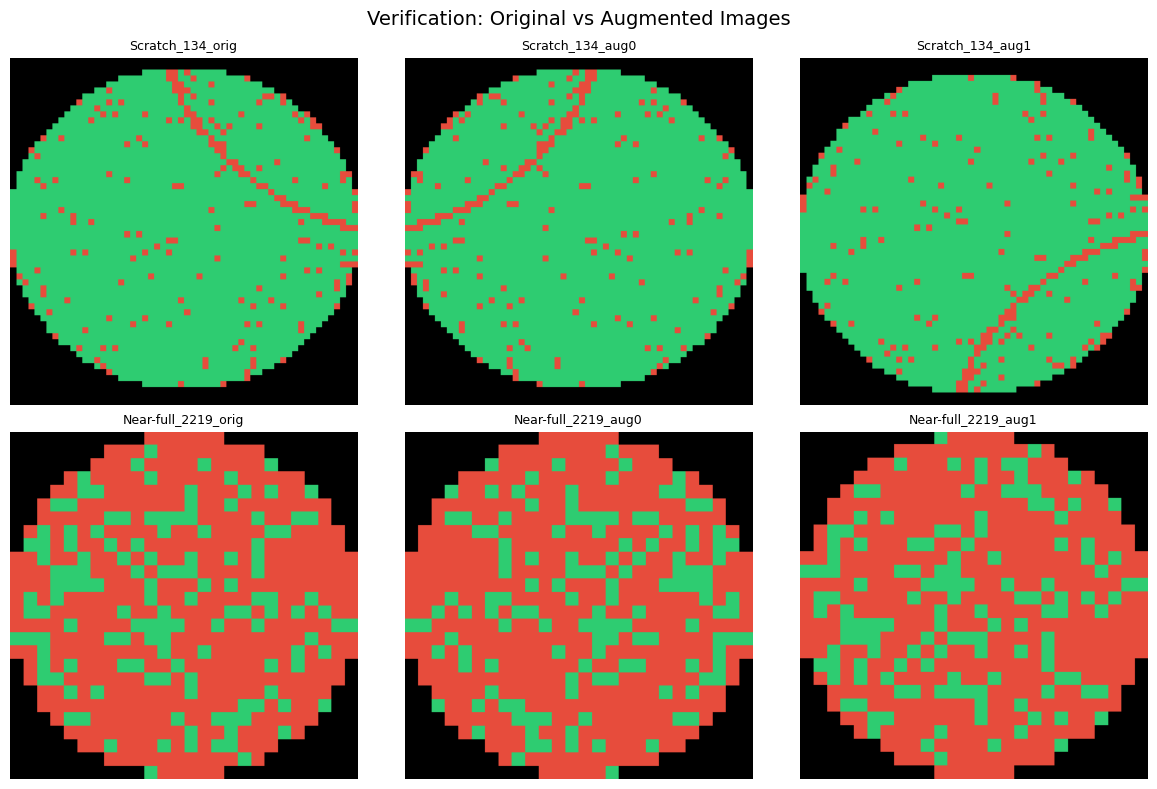

✅ If images look like wafer maps with colors, pipeline is verified!


In [1]:
# Cell 10: Verify test_run images look correct

import matplotlib.pyplot as plt
from pathlib import Path
import cv2

test_dir = Path("../data/processed/test_run")
sample_files = list(test_dir.glob("Scratch_*orig*"))[:1] + \
               list(test_dir.glob("Scratch_*aug*"))[:2] + \
               list(test_dir.glob("Near-full_*orig*"))[:1] + \
               list(test_dir.glob("Near-full_*aug*"))[:2]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Verification: Original vs Augmented Images', fontsize=14)

for idx, filepath in enumerate(sample_files):
    img = cv2.imread(str(filepath))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax = axes[idx // 3, idx % 3]
    ax.imshow(img_rgb)
    ax.set_title(filepath.stem, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("✅ If images look like wafer maps with colors, pipeline is verified!")